# Machine Learning Lab - Experiment 8

## Random Forests - Fruits Dataset

### Aim

To Classify fruit images using a Random Forest and demonstrate how majority voting across individual trees produces the final class.

In [1]:
# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import kagglehub

In [2]:
# ------------------------------------------------------------
# 2. Download the Fruits Dataset
# ------------------------------------------------------------

path = kagglehub.dataset_download(
    "shreyapmaher/fruits-dataset-images"
)

print("Path to dataset files:")
print(path)

Using Colab cache for faster access to the 'fruits-dataset-images' dataset.
Path to dataset files:
/kaggle/input/fruits-dataset-images


In [3]:
# ------------------------------------------------------------
# 3. Locate Fruit Images
# ------------------------------------------------------------

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

records = []

for root, dirs, files in os.walk(path):

    image_files = [
        f for f in files
        if os.path.splitext(f)[1].lower()
        in image_extensions
    ]

    if image_files:

        # Folder name is used as the fruit label
        label = os.path.basename(root)

        for file in image_files:

            records.append(
                (
                    os.path.join(root, file),
                    label
                )
            )


# Create DataFrame
data = pd.DataFrame(
    records,
    columns=["path", "label"]
)


# Check whether images were found
if len(data) == 0:

    raise FileNotFoundError(
        "No fruit images were found in the downloaded dataset."
    )


print("\nTotal images:", len(data))

print("\nFruit Classes:")
print(data["label"].value_counts())

print("\nFirst 5 records:")
print(data.head())


Total images: 359

Fruit Classes:
label
apple fruit         40
orange fruit        40
strawberry fruit    40
grapes fruit        40
banana fruit        40
cherry fruit        40
kiwi fruit          40
chickoo fruit       40
mango fruit         39
Name: count, dtype: int64

First 5 records:
                                                path        label
0  /kaggle/input/fruits-dataset-images/images/app...  apple fruit
1  /kaggle/input/fruits-dataset-images/images/app...  apple fruit
2  /kaggle/input/fruits-dataset-images/images/app...  apple fruit
3  /kaggle/input/fruits-dataset-images/images/app...  apple fruit
4  /kaggle/input/fruits-dataset-images/images/app...  apple fruit


In [4]:
# ------------------------------------------------------------
# 4. Limit Images Per Class
# ------------------------------------------------------------

MAX_PER_CLASS = 60

data = (
    data
    .groupby("label", group_keys=False)
    .head(MAX_PER_CLASS)
    .reset_index(drop=True)
)

print("\nImages used for training:")
print(data["label"].value_counts())



Images used for training:
label
apple fruit         40
orange fruit        40
strawberry fruit    40
grapes fruit        40
banana fruit        40
cherry fruit        40
kiwi fruit          40
chickoo fruit       40
mango fruit         39
Name: count, dtype: int64


In [5]:
# ------------------------------------------------------------
# 5. Extract HOG Features from Images
# ------------------------------------------------------------

def extract_hog(image_path):

    # Open image
    image = Image.open(image_path)

    # Convert to grayscale
    image = image.convert("L")

    # Resize image
    image = image.resize((64, 64))

    # Convert image to NumPy array
    image_array = np.asarray(
        image,
        dtype=np.float32
    ) / 255.0

    # Extract HOG features
    features = hog(
        image_array,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return features

In [6]:
# ------------------------------------------------------------
# 6. Create Feature Matrix
# ------------------------------------------------------------

features = []
labels = []

for image_path, label in zip(
    data["path"],
    data["label"]
):

    try:

        feature = extract_hog(image_path)

        features.append(feature)
        labels.append(label)

    except Exception as e:

        print(
            "Could not process:",
            image_path
        )


# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)


print("\nFeature Matrix Shape:")
print(X.shape)

print("\nClasses:")
print(np.unique(y))


Feature Matrix Shape:
(359, 1764)

Classes:
['apple fruit' 'banana fruit' 'cherry fruit' 'chickoo fruit'
 'grapes fruit' 'kiwi fruit' 'mango fruit' 'orange fruit'
 'strawberry fruit']


In [7]:
# ------------------------------------------------------------
# 7. Split Dataset into Training and Testing Data
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))



Training samples: 287
Testing samples : 72


In [8]:
# ------------------------------------------------------------
# 8. Create Random Forest Classifier
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

In [9]:
# ------------------------------------------------------------
# 9. Train the Random Forest
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)

print("\nRandom Forest training completed.")


Random Forest training completed.


In [10]:
# ------------------------------------------------------------
# 10. Make Predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test)

In [11]:
# ------------------------------------------------------------
# 11. Calculate Accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:",
      round(accuracy * 100, 2),
      "%")


Accuracy: 48.61 %


In [12]:
# ------------------------------------------------------------
# 12. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
                  precision    recall  f1-score   support

     apple fruit       0.71      0.62      0.67         8
    banana fruit       0.67      0.50      0.57         8
    cherry fruit       0.38      0.38      0.38         8
   chickoo fruit       0.67      0.50      0.57         8
    grapes fruit       0.70      0.88      0.78         8
      kiwi fruit       0.36      0.62      0.45         8
     mango fruit       0.00      0.00      0.00         8
    orange fruit       0.33      0.25      0.29         8
strawberry fruit       0.50      0.62      0.56         8

        accuracy                           0.49        72
       macro avg       0.48      0.49      0.47        72
    weighted avg       0.48      0.49      0.47        72



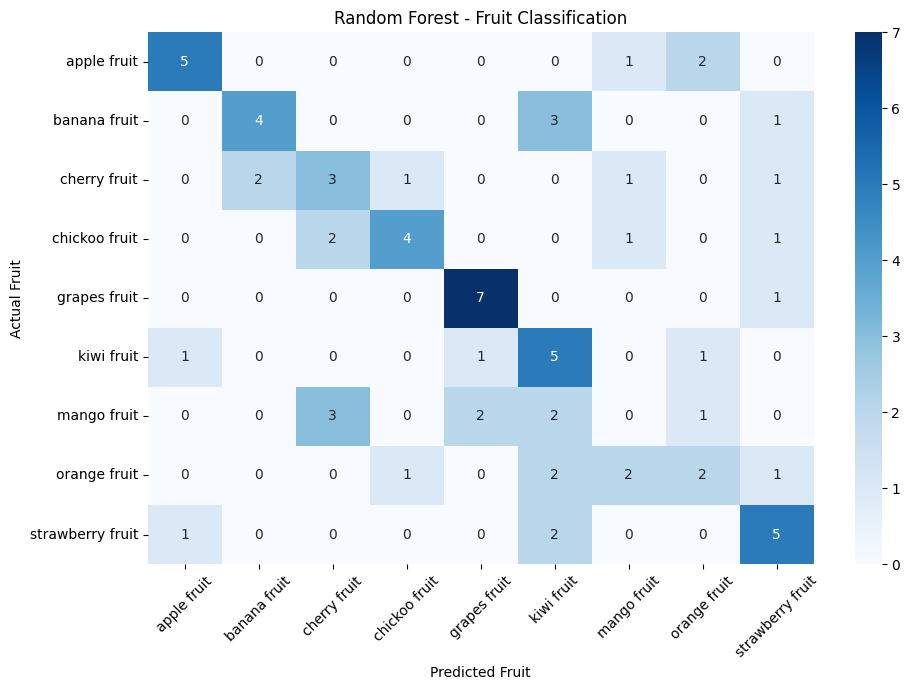

In [13]:
# ------------------------------------------------------------
# 13. Confusion Matrix
# ------------------------------------------------------------

labels_sorted = sorted(
    np.unique(y)
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_sorted
)

plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)

plt.xlabel("Predicted Fruit")
plt.ylabel("Actual Fruit")

plt.title(
    "Random Forest - Fruit Classification"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
# ------------------------------------------------------------
# 14. Demonstrate Individual Decision Tree Voting
# ------------------------------------------------------------

# Select one test image
sample = X_test[0].reshape(1, -1)


# Store predictions from every tree
tree_votes = []

for tree in model.estimators_:

    prediction = tree.predict(sample)[0]

    tree_votes.append(prediction)

In [16]:
# ------------------------------------------------------------
# 15. Count the Votes
# ------------------------------------------------------------

vote_counts = (
    pd.Series(tree_votes)
    .value_counts()
)


print("\nIndividual Tree Votes:")
print(vote_counts)



Individual Tree Votes:
0.0    41
8.0    23
4.0    17
7.0    17
6.0    15
5.0    12
2.0    12
3.0     9
1.0     4
Name: count, dtype: int64


In [17]:
# ------------------------------------------------------------
# 16. Find Majority-Voted Fruit
# ------------------------------------------------------------

final_class = vote_counts.idxmax()

majority_votes = vote_counts.max()

total_trees = len(tree_votes)


print("\n------------------------------------------------------------")
print("MAJORITY VOTING RESULT")
print("------------------------------------------------------------")

print("Total Decision Trees :", total_trees)

print("Final Fruit           :", final_class)

print("Majority Votes        :", majority_votes)



------------------------------------------------------------
MAJORITY VOTING RESULT
------------------------------------------------------------
Total Decision Trees : 150
Final Fruit           : 0.0
Majority Votes        : 41


In [18]:
# ------------------------------------------------------------
# 17. Compare with Random Forest Prediction
# ------------------------------------------------------------

rf_prediction = model.predict(sample)[0]

print("\nRandom Forest Prediction:", rf_prediction)


# Verify that both results agree
if final_class == rf_prediction:

    print(
        "Majority voting and Random Forest prediction match."
    )

else:

    print(
        "The predictions do not match."
    )


Random Forest Prediction: apple fruit
The predictions do not match.


In [19]:
# ------------------------------------------------------------
# 18. Display the Majority Voting Process
# ------------------------------------------------------------

print("\n------------------------------------------------------------")
print("TREE VOTING SUMMARY")
print("------------------------------------------------------------")

for fruit, votes in vote_counts.items():

    print(
        fruit,
        "->",
        votes,
        "votes"
    )

print("\nFinal Decision:", final_class)


------------------------------------------------------------
TREE VOTING SUMMARY
------------------------------------------------------------
0.0 -> 41 votes
8.0 -> 23 votes
4.0 -> 17 votes
7.0 -> 17 votes
6.0 -> 15 votes
5.0 -> 12 votes
2.0 -> 12 votes
3.0 -> 9 votes
1.0 -> 4 votes

Final Decision: 0.0
